# Détection de Ransomwares — Pré-processing
## Dataset : Ransomware_and_Goodware__File_API_Dataset.csv

---
## Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


---
## Chargement et exploration initiale

In [3]:
# Chargement du dataset
df = pd.read_csv('Ransomware_and_Goodware__File_API_Dataset.csv')
print('APERÇU GÉNÉRAL DU DATASET')
print(f'Dimensions       : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Colonne cible    : Label ({df["Label"].dtype})')
print(f'Colonnes features: {df.shape[1]-1} appels API Windows')
print()
print('Distribution des classes :')
counts = df['Label'].value_counts()
for label, count in counts.items():
    pct = count / len(df) * 100
    print(f'  {label:<12}: {count} échantillons ({pct:.1f}%)')
print()

APERÇU GÉNÉRAL DU DATASET
Dimensions       : 806 lignes × 65 colonnes
Colonne cible    : Label (object)
Colonnes features: 64 appels API Windows

Distribution des classes :
  Ransomware  : 412 échantillons (51.1%)
  Goodware    : 394 échantillons (48.9%)



In [4]:
#premières lignes
print('5 premières lignes (colonnes 0 à 6) :')
df.iloc[:5, :7]

5 premières lignes (colonnes 0 à 6) :


,Label,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW
0,Goodware,0,0,0,0,0,0
1,Goodware,0,7,9,15,1,22
2,Goodware,0,0,0,0,0,0
3,Goodware,0,7,19,22,23,30
4,Goodware,0,0,14,0,1,44


In [5]:
# Statistiques descriptives des features ou des colonnes sans la colonne visee
feature_cols = [c for c in df.columns if c != 'Label']
print('Statistiques descriptives (5 premières features) :')
df[feature_cols[:5]].describe().round(2)

Statistiques descriptives (5 premières features) :


,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl
count,806.00,806.00,806.00,806.0,806.00
mean,0.29,0.43,35.69,94.1,139.18
std,3.15,3.78,411.10,1229.3,3526.56
min,0.00,0.00,0.00,0.0,0.00
25%,0.00,0.00,0.00,0.0,0.00
50%,0.00,0.00,0.00,0.0,0.00
75%,0.00,0.00,8.00,2.0,3.00
max,68.00,60.00,11463.00,20001.0,99984.00


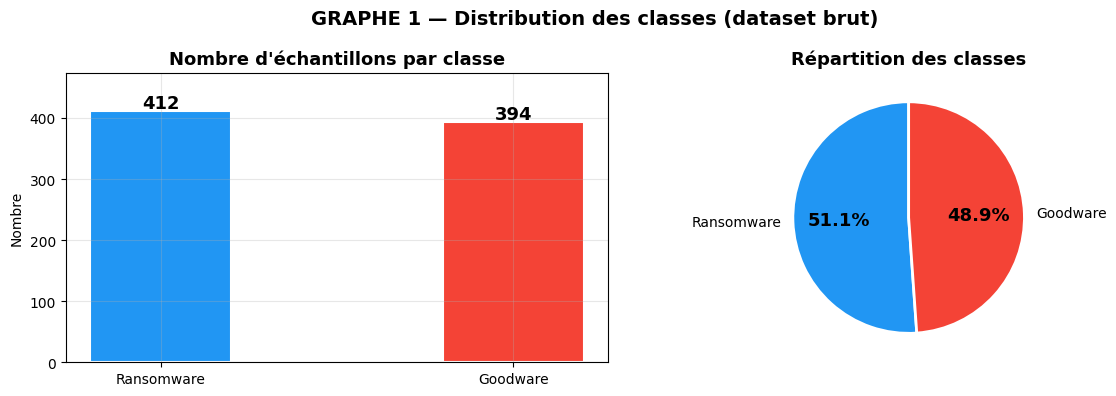

In [6]:
#distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2196F3', '#F44336']
counts = df['Label'].value_counts()

#barplot
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(val), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title("Nombre d'échantillons par classe", fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('Répartition des classes', fontweight='bold', fontsize=13)
plt.suptitle('GRAPHE 1 — Distribution des classes (dataset brut)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig01_distribution_classes.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Analyse des valeurs manquantes

In [7]:
missing_par_col = df.isnull().sum()
total_missing = missing_par_col.sum()
cols_with_missing = (missing_par_col > 0).sum()

print('ANALYSE DES VALEURS MANQUANTES')
print(f'total_missing : {total_missing}')
print(f'cols_with_missing   : {cols_with_missing}')

ANALYSE DES VALEURS MANQUANTES
total_missing : 0
cols_with_missing   : 0


---
## Détection et suppression des doublons

In [8]:
n_avant = len(df)
n_doublons = df.duplicated().sum()

print('ANALYSE DES DOUBLONS')
print(f'Lignes avant suppression : {n_avant}')
print(f'Doublons détectés        : {n_doublons} ({n_doublons/n_avant*100:.1f}%)')

#suppression
df = df.drop_duplicates().reset_index(drop=True)
print(f'Lignes après suppression : {len(df)}')
print(f'Lignes supprimées        : {n_avant - len(df)}')

ANALYSE DES DOUBLONS
Lignes avant suppression : 806
Doublons détectés        : 218 (27.0%)
Lignes après suppression : 588
Lignes supprimées        : 218


In [9]:
#vérifier la distribution après suppression des doublons
counts_clean = df['Label'].value_counts()
print('Distribution après suppression des doublons :')
for label, count in counts_clean.items():
    pct = count / len(df) * 100
    print(f'  {label:<12}: {count} ({pct:.1f}%)')

Distribution après suppression des doublons :
  Goodware    : 315 (53.6%)
  Ransomware  : 273 (46.4%)


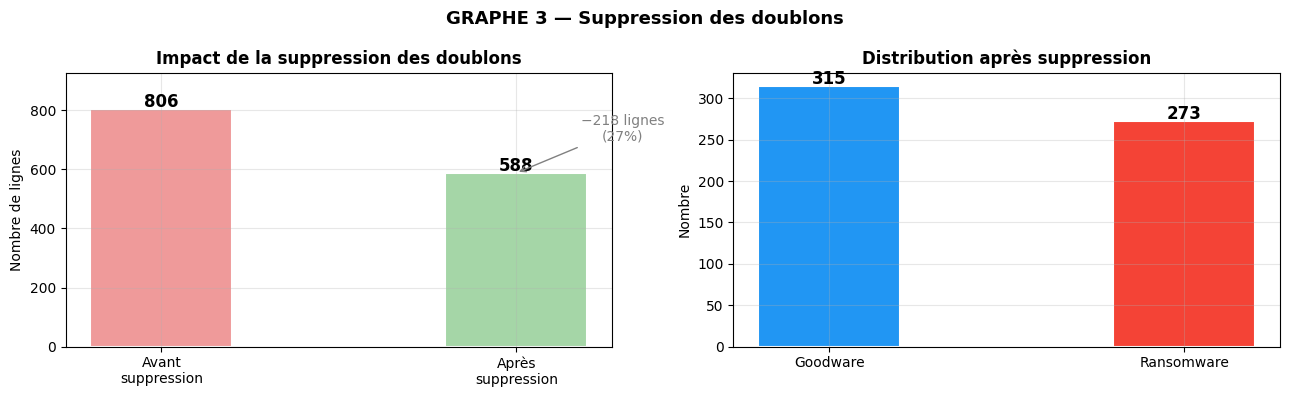

In [10]:
#impact de la suppression des doublons
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Avant/Après
categories = ['Avant\nsuppression', 'Après\nsuppression']
values = [n_avant, len(df)]
bar_colors = ['#EF9A9A', '#A5D6A7']
bars = axes[0].bar(categories, values, color=bar_colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Impact de la suppression des doublons', fontweight='bold')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_ylim(0, n_avant * 1.15)
axes[0].annotate(f'−{n_avant-len(df)} lignes\n({n_doublons/n_avant*100:.0f}%)',
                 xy=(1, len(df)), xytext=(1.3, (n_avant + len(df))/2),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=10, color='gray', ha='center')

#distribution après
colors = ['#2196F3', '#F44336']
bars2 = axes[1].bar(counts_clean.index, counts_clean.values, color=colors,
                     width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, counts_clean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution après suppression', fontweight='bold')
axes[1].set_ylabel('Nombre')

plt.suptitle('GRAPHE 3 — Suppression des doublons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_doublons.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Analyse et traitement des valeurs aberrantes (Outliers)

In [11]:
feature_cols = [c for c in df.columns if c != 'Label']

# Statistiques sur les outliers AVANT traitement
print('ANALYSE DES VALEURS ABERRANTES')
print(f'Nombre de features analysées : {len(feature_cols)}')
print()

#compter les outliers avec méthode IQR (seuil 1.5x classique)
total_outliers_avant = 0
top6 = df[feature_cols].var().nlargest(6).index.tolist()

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    total_outliers_avant += n_out

print(f'Total outliers détectés (IQR 1.5x) : {total_outliers_avant}')
print(f'  sur {len(feature_cols) * len(df)} valeurs totales')
print(f'  soit {total_outliers_avant/(len(feature_cols)*len(df))*100:.2f}% des données')

ANALYSE DES VALEURS ABERRANTES
Nombre de features analysées : 64

Total outliers détectés (IQR 1.5x) : 5216
  sur 37632 valeurs totales
  soit 13.86% des données


C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\3240448670.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\3240448670.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\3240448670.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\3240448670.py:8: MatplotlibDeprecationWarning: The 'labels' pa

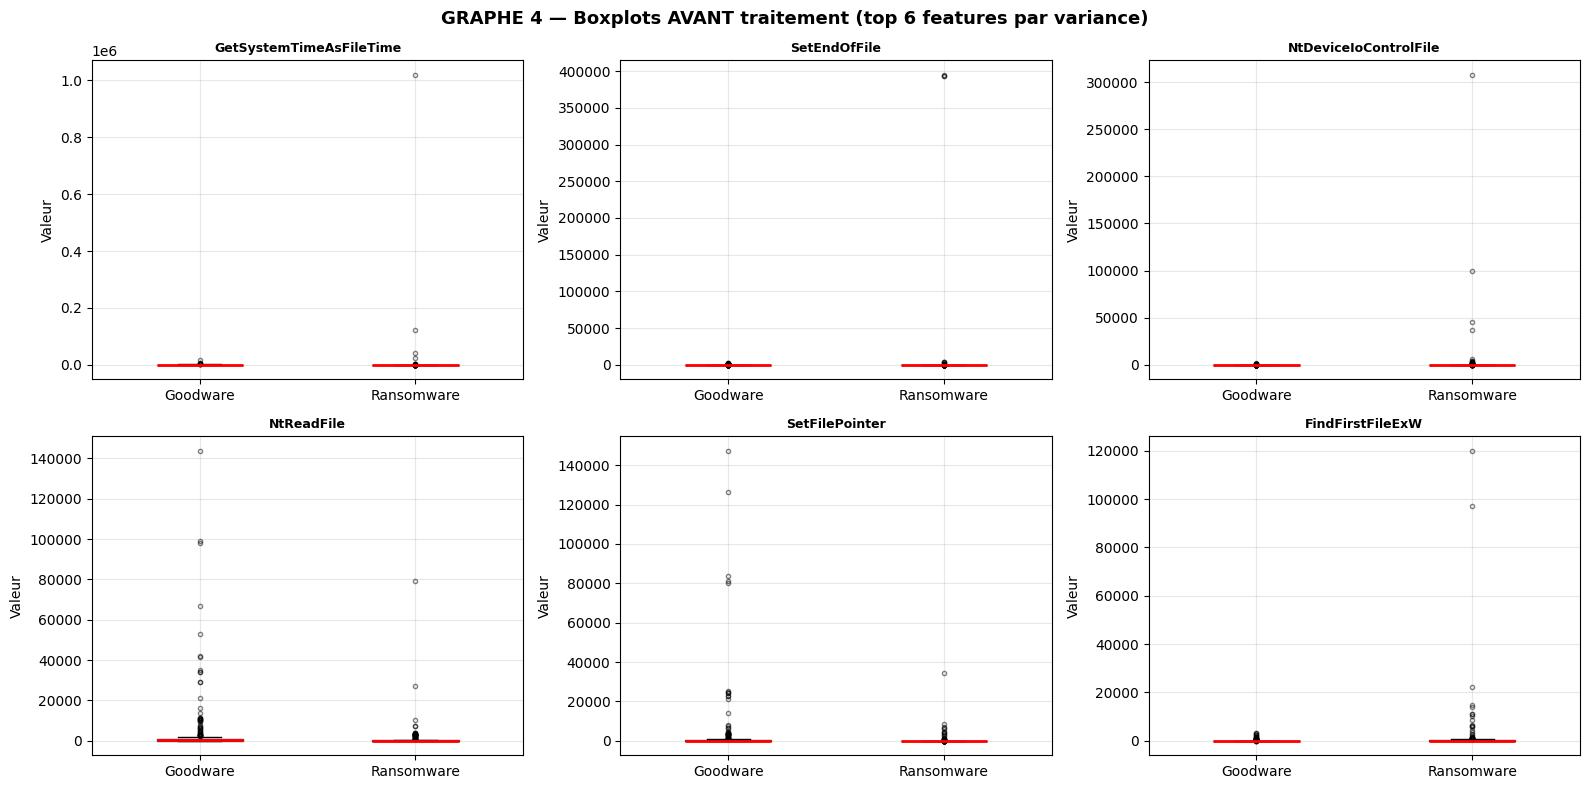

In [12]:
# Boxplots des 6 features les plus variables — AVANT traitement
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    data_g = df[df['Label']=='Goodware'][col]
    data_r = df[df['Label']=='Ransomware'][col]
    bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
                          labels=['Goodware', 'Ransomware'],
                          widths=0.4,
                          medianprops=dict(color='red', linewidth=2),
                          flierprops=dict(marker='o', markersize=3, alpha=0.5))
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#EF9A9A')
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(col[:35], fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('GRAPHE 4 — Boxplots AVANT traitement (top 6 features par variance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_boxplots_avant.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# APPLICATION DU IQR CAPPING (seuil conservateur 3×IQR)
print('Application du IQR capping (seuil 3×IQR)')
print('On ramène les valeurs extrêmes aux bornes sans les supprimer')
print()
df_clean = df.copy()
n_capped = 0
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 3 * IQR
    borne_haute = Q3 + 3 * IQR
    avant = df_clean[col].copy()
    df_clean[col] = df_clean[col].clip(lower=borne_basse, upper=borne_haute)
    n_capped += (avant != df_clean[col]).sum()

total_vals = len(feature_cols) * len(df_clean)
print(f'Valeurs plafonnées : {n_capped} / {total_vals} ({n_capped/total_vals*100:.2f}%)')
df_clean.to_csv("df_clean.csv", index=False)

Application du IQR capping (seuil 3×IQR)
On ramène les valeurs extrêmes aux bornes sans les supprimer

Valeurs plafonnées : 4239 / 37632 (11.26%)


C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\1354770206.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\1354770206.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\1354770206.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16800\1354770206.py:8: MatplotlibDeprecationWarning: The 'labels' pa

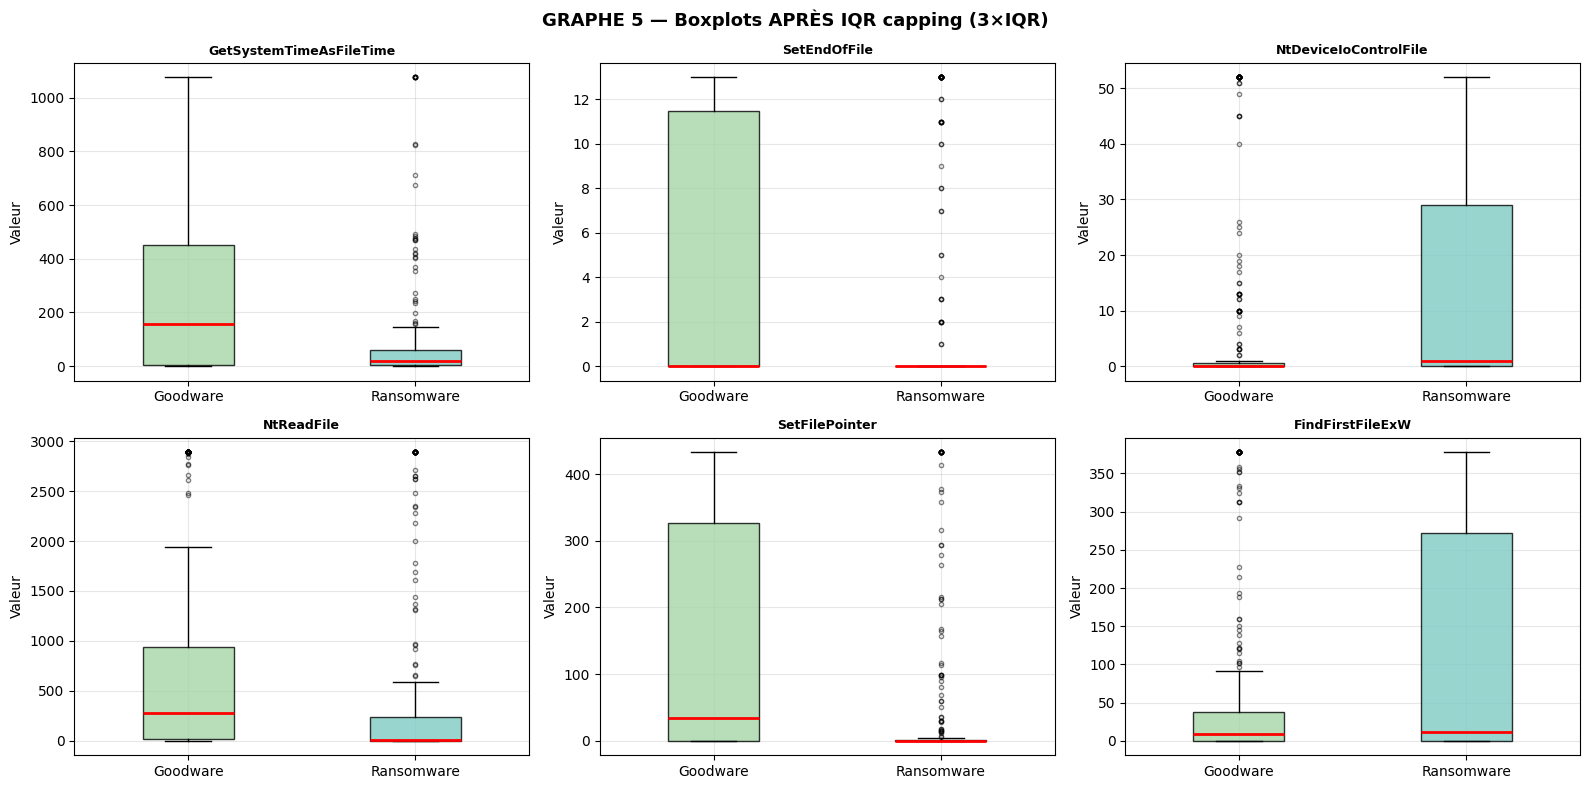

In [14]:
#boxplots APRÈS traitement
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    data_g = df_clean[df_clean['Label']=='Goodware'][col]
    data_r = df_clean[df_clean['Label']=='Ransomware'][col]
    bp = axes[i].boxplot([data_g, data_r], patch_artist=True,
                          labels=['Goodware', 'Ransomware'],
                          widths=0.4,
                          medianprops=dict(color='red', linewidth=2),
                          flierprops=dict(marker='o', markersize=3, alpha=0.5))
    bp['boxes'][0].set_facecolor('#A5D6A7')
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor('#80CBC4')
    bp['boxes'][1].set_alpha(0.8)
    axes[i].set_title(col[:35], fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('GRAPHE 5 — Boxplots APRÈS IQR capping (3×IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig05_boxplots_apres.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Encodage de la variable cible

In [15]:
print('Avant encodage :', df_clean['Label'].unique())

# Encodage : Goodware=0, Ransomware=1
df_clean['Label'] = df_clean['Label'].map({'Goodware': 0, 'Ransomware': 1})

print('Après encodage :', df_clean['Label'].unique())
print()
print('Distribution après encodage :')
vc = df_clean['Label'].value_counts()
print(f'  0 (Goodware)   : {vc.get(0, 0)} ({vc.get(0,0)/len(df_clean)*100:.1f}%)')
print(f'  1 (Ransomware) : {vc.get(1, 0)} ({vc.get(1,0)/len(df_clean)*100:.1f}%)')

Avant encodage : ['Goodware' 'Ransomware']
Après encodage : [0 1]

Distribution après encodage :
  0 (Goodware)   : 315 (53.6%)
  1 (Ransomware) : 273 (46.4%)


---
## Ingénierie de caractéristiques

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("df_clean.csv")
feature_cols = [c for c in df.columns if c != "Label"]
df_fe = df.copy()

# ─────────────────────────────
# Groupes fonctionnels
# ─────────────────────────────
file_read_cols = ["GetFileSize", "GetFileSizeEx", "NtReadFile", "SUMMARY_FILE_READ"]
file_write_cols = ["NtWriteFile", "SetEndOfFile", "SUMMARY_FILE_WRITTEN"]
file_delete_cols = ["DeleteFileW", "RemoveDirectoryA", "RemoveDirectoryW", "SUMMARY_FILE_DELETED"]
file_create_cols = ["CreateDirectoryW", "NtCreateFile", "SUMMARY_FILE_CREATED"]
file_move_cols = ["MoveFileWithProgressW", "SUMMARY_FILE_MOVED"]
file_open_cols = ["NtOpenFile", "NtOpenDirectoryObject", "SUMMARY_FILE_OPENED"]
file_query_cols = [
    "NtQueryAttributesFile", "NtQueryDirectoryFile", "NtQueryInformationFile",
    "NtQueryFullAttributesFile", "GetFileAttributesW", "GetFileAttributesExW",
    "GetFileInformationByHandle", "GetFileInformationByHandleEx"
]
network_cols = ["InternetReadFile", "URLDownloadToFileW"]
dir_cols = [
    "CreateDirectoryW", "RemoveDirectoryA", "RemoveDirectoryW",
    "SUMMARY_DIRECTORY_CREATED", "SUMMARY_DIRECTORY_ENUMERATED", "SUMMARY_DIRECTORY_REMOVED"
]
version_cols = [
    "GetFileVersionInfoExW", "GetFileVersionInfoSizeExW",
    "GetFileVersionInfoSizeW", "GetFileVersionInfoW"
]
system_info_cols = [
    "GetSystemDirectoryA", "GetSystemDirectoryW", "GetSystemTimeAsFileTime",
    "GetSystemWindowsDirectoryA", "GetSystemWindowsDirectoryW", "GetTempPathW",
    "GetVolumeNameForVolumeMountPointW", "GetVolumePathNamesForVolumeNameW",
    "GetVolumePathNameW"
]
nt_cols = [c for c in feature_cols if c.startswith("Nt")]
summary_cols = [c for c in feature_cols if c.startswith("SUMMARY_")]

# ─────────────────────────────
# 1) Agrégations
# ─────────────────────────────
df_fe["total_api_calls"]     = df[feature_cols].sum(axis=1)
df_fe["file_read_calls"]     = df[file_read_cols].sum(axis=1)
df_fe["file_write_calls"]    = df[file_write_cols].sum(axis=1)
df_fe["file_delete_calls"]   = df[file_delete_cols].sum(axis=1)
df_fe["file_create_calls"]   = df[file_create_cols].sum(axis=1)
df_fe["file_move_calls"]     = df[file_move_cols].sum(axis=1)
df_fe["file_open_calls"]     = df[file_open_cols].sum(axis=1)
df_fe["file_query_calls"]    = df[file_query_cols].sum(axis=1)
df_fe["nt_total_calls"]      = df[nt_cols].sum(axis=1)
df_fe["summary_total_calls"] = df[summary_cols].sum(axis=1)
df_fe["network_calls"]       = df[network_cols].sum(axis=1)
df_fe["dir_activity"]        = df[dir_cols].sum(axis=1)
df_fe["version_info_calls"]  = df[version_cols].sum(axis=1)
df_fe["system_info_calls"]   = df[system_info_cols].sum(axis=1)

# ─────────────────────────────
# 2) Ratios
# ─────────────────────────────
df_fe["write_read_ratio"]       = df_fe["file_write_calls"] / (df_fe["file_read_calls"] + 1)
df_fe["delete_create_ratio"]    = df_fe["file_delete_calls"] / (df_fe["file_create_calls"] + 1)
df_fe["write_vs_delete_ratio"]  = df_fe["file_write_calls"] / (df_fe["file_delete_calls"] + 1)
df_fe["nt_to_total_ratio"]      = df_fe["nt_total_calls"] / (df_fe["total_api_calls"] + 1)
df_fe["summary_to_total_ratio"] = df_fe["summary_total_calls"] / (df_fe["total_api_calls"] + 1)
df_fe["query_to_total_ratio"]   = df_fe["file_query_calls"] / (df_fe["total_api_calls"] + 1)
df_fe["dir_to_total_ratio"]     = df_fe["dir_activity"] / (df_fe["total_api_calls"] + 1)

# ─────────────────────────────
# 3) Binary flags
# ─────────────────────────────
df_fe["has_network_activity"] = (df[network_cols].sum(axis=1) > 0).astype(int)
df_fe["has_file_deletion"] = (df_fe["file_delete_calls"] > 0).astype(int)
df_fe["has_mass_writes"] = (df_fe["file_write_calls"] > df_fe["file_write_calls"].median()).astype(int)
df_fe["has_dir_traversal"] = (df_fe["dir_activity"] > df_fe["dir_activity"].median()).astype(int)
df_fe["has_encryption_pattern"] = (
    (df_fe["file_write_calls"] > df_fe["file_write_calls"].median()) &
    (df_fe["file_delete_calls"] > df_fe["file_delete_calls"].median())
).astype(int)
df_fe["has_mass_enumeration"] = (
    (df["FindFirstFileExW"] + df["FindFirstFileExA"]) >
    (df["FindFirstFileExW"] + df["FindFirstFileExA"]).median()
).astype(int)

# ─────────────────────────────
# 4) Diversité / sparsité
# ─────────────────────────────
df_fe["active_api_count"] = (df[feature_cols] > 0).sum(axis=1)
df_fe["zero_ratio"] = (df[feature_cols] == 0).sum(axis=1) / len(feature_cols)
df_fe["max_single_api"] = df[feature_cols].max(axis=1)
df_fe["std_api_calls"] = df[feature_cols].std(axis=1)
df_fe["mean_api_calls"] = df[feature_cols].mean(axis=1)

# ─────────────────────────────
# 5) Encodage cible
# ─────────────────────────────
df_fe["label_encoded"] = (df["Label"] == "Ransomware").astype(int)


---
## 7. Analyse des corrélations et features discriminantes

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# ── Chargement ───────────────────────────────────────────────────
df     = df_fe.copy()
target = "label_encoded"
fcols  = [c for c in df.columns if c not in ["Label", "label_encoded"]]
X, y   = df[fcols], df[target]

# ── 1. Suppression des features corrélées > 0.90 ─────────────────
corr  = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop  = [c for c in upper.columns if any(upper[c] > 0.90)]
X_red = X.drop(columns=drop)

# ── 2. Matrice de corrélation — 20 features top variance ─────────
top20_var  = X_red.var().nlargest(20).index.tolist()
corr_20    = X_red[top20_var].corr()
labels_20  = [c[:15] for c in top20_var]
mask_upper = np.triu(np.ones_like(corr_20, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_20, mask=mask_upper, cmap="Greens", vmin=0, vmax=1,
            square=True, linewidths=0.5, linecolor="#e0e0e0",
            annot=True, fmt=".1f", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.75, "label": "Corrélation"},
            xticklabels=labels_20, yticklabels=labels_20, ax=ax)
ax.set_title("Matrice de corrélation — Top 20 features (triangle inférieur)", fontsize=13, pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.close()

# ── 3. Mann-Whitney U test — Top 30 ──────────────────────────────
res = []
for col in X_red.columns:
    _, p = mannwhitneyu(X_red[y==0][col], X_red[y==1][col], alternative="two-sided")
    res.append({"feature": col, "neg_logp": -np.log10(max(p, 1e-30))})
mw     = pd.DataFrame(res).sort_values("neg_logp", ascending=False)
top_mw = mw.head(20).sort_values("neg_logp")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_mw["feature"], top_mw["neg_logp"], color="#1565C0", edgecolor="none", height=0.65)
ax.axvline(-np.log10(0.05), color="#E53935", ls="--", lw=1.5, label="p = 0.05")
ax.set_xlabel("$-\\log_{10}$(p-value)", fontsize=11)
ax.set_title("Test Mann-Whitney U — Top 20 features", fontsize=12)
ax.tick_params(axis="y", labelsize=8.5)
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=9)
plt.subplots_adjust(left=0.40)
plt.savefig("mann_whitney_pvalues.png", dpi=150, bbox_inches="tight")
plt.close()

# ── 4. Mutual Information — Top 30 ───────────────────────────────
mi     = mutual_info_classif(X_red, y, random_state=42)
mi_df  = pd.DataFrame({"feature": X_red.columns, "mi_score": mi}).sort_values("mi_score", ascending=False)
top_mi = mi_df.head(20).sort_values("mi_score")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_mi["feature"], top_mi["mi_score"], color="#2E7D32", edgecolor="none", height=0.65)
ax.set_xlabel("Score d'information mutuelle", fontsize=11)
ax.set_title("Information Mutuelle — Top 20 features", fontsize=12)
ax.tick_params(axis="y", labelsize=8.5)
ax.spines[["top","right"]].set_visible(False)
plt.subplots_adjust(left=0.40)
plt.savefig("mutual_information_top20.png", dpi=150, bbox_inches="tight")
plt.close()

# ── 5. Random Forest — Top 30 ────────────────────────────────────
rf    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_red, y)
rf_df = pd.DataFrame({"feature": X_red.columns, "importance": rf.feature_importances_})\
          .sort_values("importance", ascending=False)
top_rf = rf_df.head(20).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_rf["feature"], top_rf["importance"], color="#BF360C", edgecolor="none", height=0.65)
ax.set_xlabel("Importance (Gini)", fontsize=11)
ax.set_title("Importance Random Forest — Top 20 features", fontsize=12)
ax.tick_params(axis="y", labelsize=8.5)
ax.spines[["top","right"]].set_visible(False)
plt.subplots_adjust(left=0.40)
plt.savefig("rf_importance_top20.png", dpi=150, bbox_inches="tight")
plt.close()

# ── 6. Vote majoritaire >= 2/3 ───────────────────────────────────
votes = {}
for f in X_red.columns:
    score = 0
    if f in set(mw.head(30)["feature"]):    score += 1
    if f in set(mi_df.head(30)["feature"]): score += 1
    if f in set(rf_df.head(30)["feature"]): score += 1
    votes[f] = score

selected = sorted([f for f, v in votes.items() if v >= 2])
X_final  = X_red[selected].copy()
X_final["label_encoded"] = y.values
X_final.to_csv("df_selected.csv", index=False)
print(f"Features retenues : {len(selected)} | Dataset final : {X_final.shape}")

Features retenues : 30 | Dataset final : (588, 31)


---
## Transformations des données

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
import joblib

df_sel = pd.read_csv("df_selected.csv")
target = "label_encoded"
fcols  = [c for c in df_sel.columns if c != target]
X, y   = df_sel[fcols].copy(), df_sel[target]

# ── Visualisation effet log1p (1 feature) ────────────────────────
col  = "CreateDirectoryW"
good = df_sel[df_sel[target]==0][col].values
rans = df_sel[df_sel[target]==1][col].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panels = [
    (good,            rans,            "Avant log1p",  "Nombre d'appels"),
    (np.log1p(good),  np.log1p(rans),  "Apres log1p",  "log1p(appels)")
]
for ax, (g, r, title, xlabel) in zip(axes, panels):
    for data, color, label in [(g, "#1565C0", "Goodware"), (r, "#C62828", "Ransomware")]:
        kde = gaussian_kde(data, bw_method=0.35)
        xs  = np.linspace(data.min(), data.max(), 300)
        ax.fill_between(xs, kde(xs), alpha=0.30, color=color)
        ax.plot(xs, kde(xs), color=color, lw=2, label=label)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Densite", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle("CreateDirectoryW : effet de log1p sur la separabilite", fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig("log1p_effect.png", dpi=150, bbox_inches="tight")
plt.close()

# ── Transformation complète ──────────────────────────────────────
ratio_cols = [c for c in fcols if "ratio" in c]
count_cols = [c for c in fcols if c not in ratio_cols]

X[count_cols] = np.log1p(X[count_cols])
scaler = StandardScaler()
X[fcols] = scaler.fit_transform(X[fcols])
joblib.dump(scaler, "scaler.pkl")

df_transformed = X.copy()
df_transformed[target] = y.values
df_transformed.to_csv("df_transformed.csv", index=False)
print(f"Dataset transforme : {df_transformed.shape}")

Dataset transforme : (588, 31)
